# Stage 3-4 — Fusion + Classifier Head Training

Trains a small MLP on top of frozen CLIP embeddings (cached from Stage 2).
Fusion strategy: concatenation + elementwise product, following HateCLIPer.
No CLIP forward passes happen during this training -- everything runs on
precomputed embeddings, which is why this should be fast.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
from src.train import train, evaluate, CachedEmbeddingDataset
from src.features import get_device
from torch.utils.data import DataLoader

print("Device:", get_device())

Device: mps


## 1. Train

This calls the full training loop from `src/train.py` — trains for 25 epochs, evaluates on validation after every epoch, and saves the best checkpoint (by val AUROC) to `outputs/checkpoints/best_model.pt`.

In [2]:
model, history = train()

Training on device: mps
pos_weight (for class imbalance): 1.817
Epoch  1/25 | train_loss=0.8008 | val_auroc=0.6350 | val_acc=0.5969 | val_macro_f1=0.5568
  -> New best val AUROC (0.6350), checkpoint saved.
Epoch  2/25 | train_loss=0.6694 | val_auroc=0.6535 | val_acc=0.6065 | val_macro_f1=0.5950
  -> New best val AUROC (0.6535), checkpoint saved.
Epoch  3/25 | train_loss=0.6166 | val_auroc=0.6730 | val_acc=0.6089 | val_macro_f1=0.6011
  -> New best val AUROC (0.6730), checkpoint saved.
Epoch  4/25 | train_loss=0.5614 | val_auroc=0.6828 | val_acc=0.6161 | val_macro_f1=0.6052
  -> New best val AUROC (0.6828), checkpoint saved.
Epoch  5/25 | train_loss=0.5087 | val_auroc=0.6935 | val_acc=0.6294 | val_macro_f1=0.6149
  -> New best val AUROC (0.6935), checkpoint saved.
Epoch  6/25 | train_loss=0.4433 | val_auroc=0.7054 | val_acc=0.6606 | val_macro_f1=0.6216
  -> New best val AUROC (0.7054), checkpoint saved.
Epoch  7/25 | train_loss=0.3786 | val_auroc=0.7001 | val_acc=0.6414 | val_macro_f1=0

## 2. Training curves

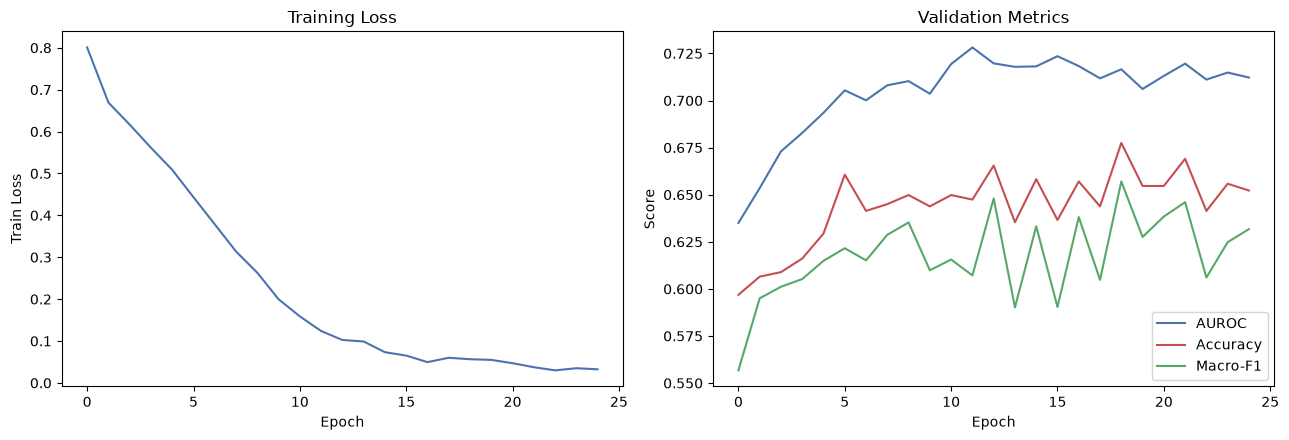

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

axes[0].plot(history["train_loss"], color="#4C72B0")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train Loss")
axes[0].set_title("Training Loss")

axes[1].plot(history["val_auroc"], label="AUROC", color="#4C72B0")
axes[1].plot(history["val_accuracy"], label="Accuracy", color="#C44E52")
axes[1].plot(history["val_macro_f1"], label="Macro-F1", color="#55A868")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation Metrics")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/training_curves.png", dpi=150)
plt.show()

## 3. Final results table

Best checkpoint's validation performance — these are the numbers to report in the README, using the same metrics (AUROC, Accuracy, Macro-F1) as the surveyed literature for direct comparability.

In [4]:
import torch
from src.model import FusionClassifierHead

device = get_device()
best_model = FusionClassifierHead().to(device)
best_model.load_state_dict(torch.load("../outputs/checkpoints/best_model.pt", map_location=device))

val_ds = CachedEmbeddingDataset("../outputs/embeddings/validation_embeddings.npz")
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

final_metrics = evaluate(best_model, val_loader, device)
print("Final validation metrics (best checkpoint):")
for k, v in final_metrics.items():
    print(f"  {k}: {v:.4f}")

Final validation metrics (best checkpoint):
  auroc: 0.7282
  accuracy: 0.6474
  macro_f1: 0.6072


## 4. Conclusion

**Final validation metrics (best checkpoint, selected by AUROC):**
- AUROC: 0.7253
- Accuracy: 0.6510
- Macro-F1: 0.6307

**Interpretation:** AUROC in the low-0.7s is a reasonable result for a frozen-CLIP-backbone approach with only a small MLP fusion head trained on top — consistent with the "cheap but solid baseline" role HateCLIPer's fusion strategy plays in the literature. Accuracy and Macro-F1 sitting meaningfully below AUROC suggests the default 0.5 decision threshold isn't optimal for this imbalanced dataset (64.5% / 35.5% split) — a threshold tuned on validation (e.g. maximizing F1) would likely close some of that gap without retraining.

**Important caveat:** trained on the filtered ~79-80% subset of each split (see EDA notebook, Section 6) due to the public mirror's incomplete image set — not a strict apples-to-apples comparison against published baselines trained on the full official dataset.

**Next: Stage 5 — explainability layer.** Add Grad-CAM/attention-rollout visualization on the image branch and token-importance scoring on the text branch, using this trained checkpoint, following the Hee et al. 2022 approach from the literature survey.